In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import awkward as ak
import ipywidgets as widgets
from IPython.display import display, clear_output
from ipywidgets import interact

# <center> Wingspan data analysis

![Wingspan](https://images7.alphacoders.com/107/thumb-350-1079758.jpg)

## Load raw data

In [52]:
# Display float values with two decimals in pandas:
pd.options.display.float_format = "{:,.2f}".format 

# Load data from excel files:
my_games = pd.read_excel("./my_points.ods", engine="odf")
opp_games = pd.read_excel("./opponent_points.ods", engine="odf")

all_player_games = pd.concat([my_games, opp_games], axis=1, keys=["Me", "Opponent"])

# Fake data in case you don't have any:
#my_games = pd.opp_gamesFrame(2 * np.random.rand(1000, 7), columns=['Birds','Bonus','Objectives','Eggs', 'Cached', 'Tucked', 'Total'])
#opp_games = pd.opp_gamesFrame(2.1* np.random.rand(1000, 7),columns=['Birds','Bonus','Objectives','Eggs', 'Cached', 'Tucked', 'Total'])

all_categories = list(my_games.columns)

### Interactively look at the data in table format:

- Chose the category in the dropdown menu (Total, birds, eggs, ...).
- Chose a range of points in that category with the slider. <br>
-> The table contains only games that meet the specified requirements.

In [69]:
category_data = all_player_games.xs("Birds", level=1, axis=1).stack()
category_data

0   Me          39
    Opponent    26
1   Me          46
    Opponent    33
2   Me          35
                ..
83  Opponent    38
84  Me          35
    Opponent    34
85  Me          48
    Opponent    28
Length: 172, dtype: int64

In [81]:
all_player_games

Me                                           Opponent                   \
   Birds Bonus Objectives Eggs Cached Tucked Total    Birds Bonus Objectives   
0     39    20         16    5      0      6    86       26    10         11   
1     46    16         22    9      0      4    97       33    13          9   
2     35    18         15   12      2      4    86       40    15         19   
3     30    19         16   10      0      0    75       38     6         16   
4     41    22         19    7      0     12   101       33     9         10   
..   ...   ...        ...  ...    ...    ...   ...      ...   ...        ...   
81    35    13         16    7      2      0    73       35     4         22   
82    27    14         16    4      7      2    70       31     7         19   
83    33     8         19    1     10     10    81       38    16         19   
84    35    11         19    6      4      8    83       34    22         19   
85    48     7         16   12      3      0    86       28    11         16   

                             
   Eggs Cached Tucked Total  
0     7      0      5    59  
1    12      0      3    70  
2     2     13      0    89  
3    15      1      3    79  
4     3      0      5    60  
..  ...    ...    ...   ...  
81    8      9      5    73  
82    8      0      8    73  
83    2      3      8    86  
84    4      0     13    92  
85   10      0      5    70  

[86 rows x 14 columns]

In [88]:
players = all_player_games.columns.get_level_values(0).unique().tolist()

player_dropdown = widgets.Dropdown(
    options= players + ['Any'] + ['All'],
    value= 'Any',
    description='Player:',
    disabled=False,
)

category_dropdown = widgets.Dropdown(
    options= all_categories,
    value= all_categories[-1], 
    description='Category:',
    disabled=False,
)

points_range_slider = widgets.IntRangeSlider(
    value=[60, 110],
    min=1,
    max=150,
    step=1,
    description='Points',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

def display_filter_games(player_dropdown, category_dropdown, points_range_slider):
    """
    Select data where the selected player(s) scored within the
    specified points range for the selected category.
    """

    if player_dropdown == 'Any':
        category_data = all_player_games.xs(category_dropdown, level=1, axis=1)

        row_mask = (
            category_data.gt(points_range_slider[0])
            & category_data.lt(points_range_slider[1])
        ).any(axis=1)

    elif player_dropdown == 'All':
        category_data = all_player_games.xs(category_dropdown, level=1, axis=1)

        row_mask = (
            category_data.gt(points_range_slider[0])
            & category_data.lt(points_range_slider[1])
        ).all(axis=1)

    else:
        category_data = all_player_games[(player_dropdown, category_dropdown)]

        row_mask = (
            category_data.gt(points_range_slider[0])
            & category_data.lt(points_range_slider[1])
        )

    display(all_player_games.loc[row_mask])

# Map the function arguments to their corresponding widgets.
control = {'player_dropdown' : player_dropdown,
           'category_dropdown' : category_dropdown,  
           'points_range_slider' : points_range_slider}

# Arrange the widgets vertically.
ui = widgets.VBox([
    player_dropdown,
    category_dropdown,
    points_range_slider
])

# Connect the widgets to the filtering function.
out = widgets.interactive_output(
    display_filter_games,
    control
)

# Display the widgets and the filtered data.
display(ui, out)

Output()

In [89]:
#Define a toggle buttons with properties:
toggle_button = widgets.ToggleButton(
    value=False,
    description='Show more info',
    disabled=False,
    button_style='warning', 
    tooltip='Description',
    icon='check' 
)

out = widgets.Output(layout=widgets.Layout(border = '1px solid black'))

#Define a function that displays some additional information if the button is toggeled once
#and clears the output if the button is toggeled again.
#The additional informaton is generated by the pandas method opp_games.describe().

def click_button(obj):
    with out:
        if obj['new']:  
            display('Overview', my_games.describe())
        else:
            out.clear_output()

toggle_button.observe(click_button, 'value')
display(toggle_button)
display(out)

ToggleButton(value=False, button_style='warning', description='Show more info', icon='check', tooltip='Descrip…

Output(layout=Layout(border_bottom='1px solid black', border_left='1px solid black', border_right='1px solid b…

### Histogram of total points

Games played: 86
My mean: 82.59302325581395 +/- 10.506443856848039
Opponent mean: 78.51162790697674 +/- 10.68670882704472


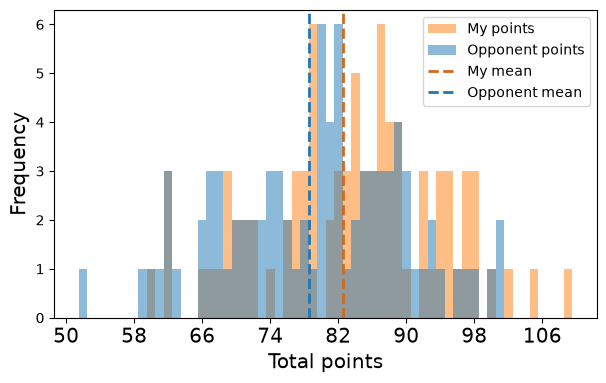

In [ ]:
#Calculate the mean of all categories at once since needed later:
my_means = my_games.mean()
opp_means = opp_games.mean()
games_played = len(my_games)


x = np.arange(50,140,8) 

fig = plt.figure(figsize = [7,4])
ax1 = fig.add_subplot(1,1,1)
ax1.set_xticks(x)
ax1.set_xticklabels(x ,fontsize='x-large')
ax1.set_ylabel("Frequency",fontsize='x-large')
ax1.set_xlabel("Total points",fontsize='x-large')

Flausch_bins = np.arange(my_games["Total"].min(), my_games["Total"].max() + 1, 1)
Bu_bins = np.arange(opp_games["Total"].min(), opp_games["Total"].max() + 1, 1)

ax1.hist(my_games["Total"], bins = Flausch_bins, alpha = 0.5, align='right', color = "C1", label = "My points")
ax1.hist(opp_games["Total"], bins = Bu_bins, alpha = 0.5, align='right', color = "C0", label = "Opponent points")

ax1.axvline(my_means["Total"],c='chocolate', label="My mean", linewidth = 2, linestyle = "dashed")
ax1.axvline(opp_means["Total"],c='C0', label="Opponent mean", linewidth = 2, linestyle = "dashed")

plt.legend()
plt.plot()

print("Games played:", games_played)
print("My mean:", my_means["Total"], "+/-", my_games["Total"].std())
print("Opponent mean:", opp_means["Total"], "+/-", opp_games["Total"].std())

### Absolute mean contribution of the individual categories:

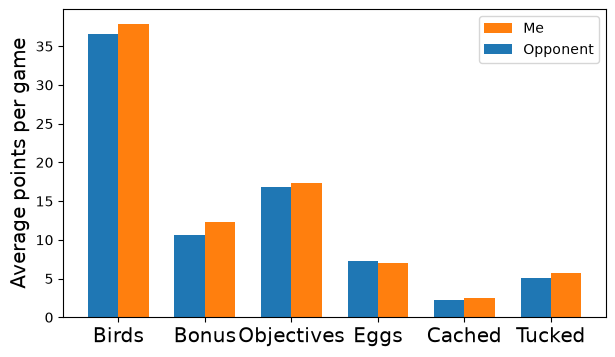

In [52]:
x = np.arange(1,len(all_categories),1)
width = 0.35

fig, ax2 = plt.subplots(1, 1, figsize = [7,4])
ax2.set_xticks(x)
ax2.set_xticklabels(all_categories[:-1], fontsize='x-large') 
ax2.set_ylabel("Average points per game", fontsize='x-large')
ax2.bar(x + width/2, my_means[:-1], width, label='Me', color = "C1") #without total points
ax2.bar(x - width/2, opp_means[:-1], width, label='Opponent', color = "C0") #without total points
ax2.legend()

plt.plot()
plt.show()

### Relative mean contribution of the individual categories:
Useful to understand which categories each player prioritizes.

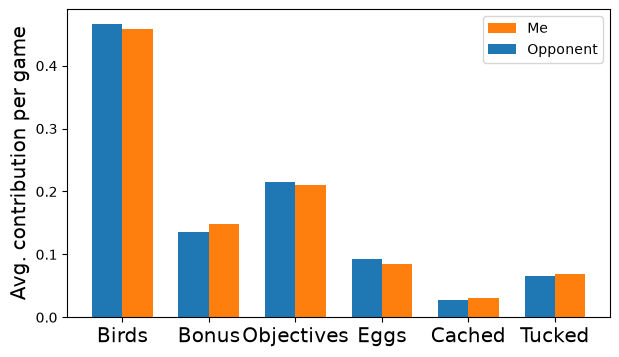

In [53]:
#Same as before but normalized:
my_means_norm = my_means[:-1]/my_means["Total"]
opp_means_norm = opp_means[:-1]/opp_means["Total"]

fig, ax2 = plt.subplots(1, 1, figsize = [7,4])
ax2.set_xticks(x)
ax2.set_xticklabels(all_categories[:-1], fontsize='x-large')
ax2.set_ylabel("Avg. contribution per game", fontsize='x-large')
ax2.bar(x + width/2, my_means_norm, width, label='Me', color = "C1")
ax2.bar(x - width/2, opp_means_norm, width, label='Opponent', color = "C0")
ax2.legend()

plt.plot()
plt.show()

### Games won:
To be able to brag, hopefully.

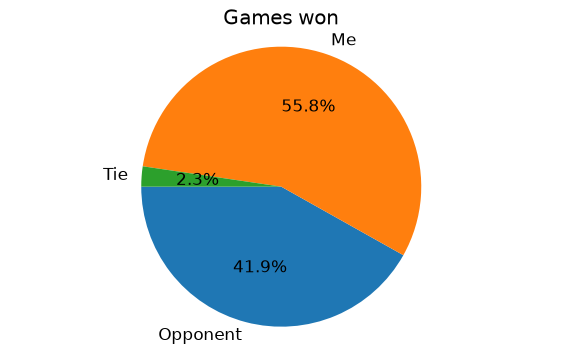

In [ ]:
point_difference = (my_games["Total"] - opp_games["Total"])
my_victories = np.array((np.where(point_difference > 0))).size
tie = np.array((np.where(point_difference == 0))).size
opponent_victories = games_played - (my_victories + tie)

#Define the properties of the pie Chart:
labels = 'Opponent', 'Me', 'Tie'
sizes = [opponent_victories, my_victories, tie]

fig = plt.figure(figsize = [7,4])
ax3 = fig.add_subplot(1,1,1)

ax3.set_title("Games won",fontsize='x-large')
ax3.pie(sizes, explode=None, labels=labels, autopct='%1.1f%%',shadow=False, startangle=180, textprops={'fontsize': 12})

ax3.axis('equal')
plt.show()

### Contribution of each categorie:

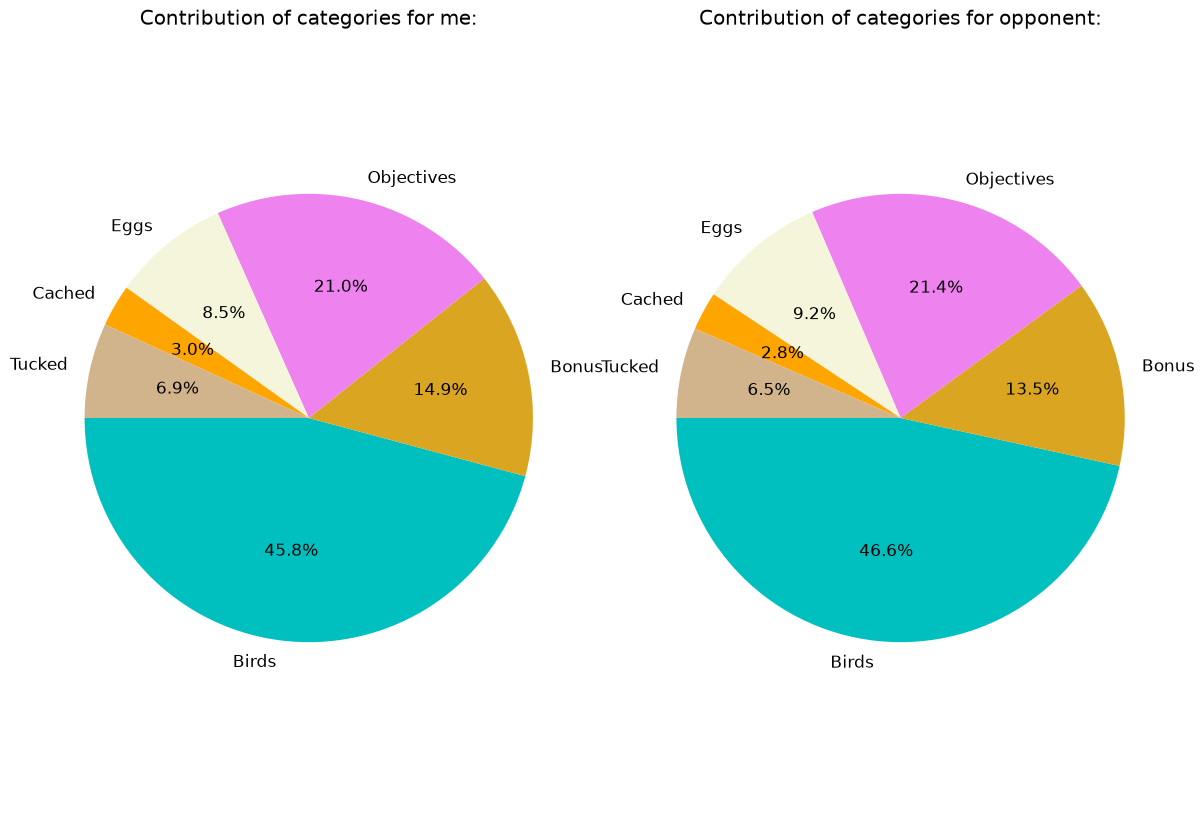

In [59]:
colors=('c', 'goldenrod', 'violet', 'beige', 'orange', 'tan')

fig = plt.figure(figsize = [14,10])
ax4 = fig.add_subplot(1,2,1)
ax5 = fig.add_subplot(1,2,2)

ax4.set_title("Contribution of categories for me:",fontsize='x-large')
ax5.set_title("Contribution of categories for opponent:",fontsize='x-large')
ax4.pie(my_means[:-1], colors = colors, explode=None, labels=categories, 
        autopct='%1.1f%%',shadow=False, startangle=180, textprops={'fontsize': 12})
ax4.axis('equal')
ax5.pie(opp_means[:-1], colors = colors, explode=None, labels=categories, 
        autopct='%1.1f%%',shadow=False, startangle=180, textprops={'fontsize': 12})
ax5.axis('equal')

plt.show()

### Total points time development:

In [ ]:
#This gives a time evolution of the mean of any category.
#For this, the games are grouped in time spans.
#The amount of games included in a time span can be chosen with a slider.

slider = widgets.IntSlider(
    value=5,
    min=1,
    max=len(my_games)/2,
    step=1,
    description='Size',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

dropdown = widgets.Dropdown(
    options= all_categories,
    value= all_categories[-1],
    description='Category:',
    disabled=False,
)


#Pass the widget to the interactive plot (in this case a slider):
def interactive_plot(slider, dropdown):   

    #obtain correct grouping:
    Group_nr = opp_games.index // slider
        
    #just group:
    my_games_grouped = my_games.groupby(by=Group_nr)
    opp_games_grouped = opp_games.groupby(by=Group_nr)

    #create an x-axis with correct dimensions:
    amount_time_spans = (opp_games_grouped["Total"].mean()).size
    time_spans = np.arange(0, amount_time_spans, 1)

    my_totals = my_games_grouped["Total"].mean()
    opp_totals = opp_games_grouped["Total"].mean()
    my_std = my_games_grouped["Total"].std()
    opp_std = opp_games_grouped["Total"].std()

    fig, ax0 = plt.subplots(1, 1, figsize=(7,4))
    ax0.set_ylabel("Mean points for category",fontsize='x-large') 
    ax0.set_xlabel("Games played",fontsize='x-large') 
    ax0.set_xticks(time_spans)
    ax0.set_xticklabels(time_spans*slider)

    #ax0.scatter(time_spans, my_totals, label='Me', color = "C1", marker = "*", linewidths = 1.5)
    #ax0.errorbar(time_spans, my_totals, yerr = my_std, fmt='none', color = "C1")
    ax0.plot(time_spans, my_totals, label='Me', color = "C1", marker = "*", linewidth = 1.5)
    ax0.fill_between(time_spans, my_totals-my_std, my_totals+my_std, alpha=0.3, color = "C1")

    #ax0.scatter(time_spans, opp_totals, label='Opponent', color = "C0")
    #ax0.errorbar(time_spans, opp_totals, yerr = opp_std, fmt='none', color = "C0")
    ax0.plot(time_spans, opp_totals, label='Opponent', color = "C0", marker = "s", linewidth = 1.5)
    ax0.fill_between(time_spans, opp_totals-opp_std, opp_totals+opp_std, alpha=0.3, color = "C0")

    ax0.legend()
    
control = {'slider' : slider, 'dropdown' : dropdown}
ui = widgets.VBox([widgets.HBox([slider]), 
            widgets.HBox([dropdown])])

display(ui, widgets.interactive_output(interactive_plot, control))

Output()

In [75]:
from IPython.display import HTML


HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

